# Predictive Maintenance and Anomaly Detection in Aircraft Engines Using Multivariate Sensor Data

### Mount Drive & Extract ZIP.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Extract Zip.

In [2]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/Nasa_CMaps_Data.zip"
extract_path = "/content/nasa_data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

os.listdir(extract_path)

['Data']

## 1. Load the data.

In [3]:
import pandas as pd
import numpy as np

# Column names
cols = ['unit_number', 'time_in_cycles', 'op_setting_1',
        'op_setting_2', 'op_setting_3']

sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
cols.extend(sensor_cols)

In [5]:
base_path = '/content/nasa_data/Data/'

# Load train
train = pd.read_csv(base_path + 'train_FD001.txt',
                    sep=r'\s+', header=None)
train.columns = cols

# Load test
test = pd.read_csv(base_path + 'test_FD001.txt',
                   sep=r'\s+', header=None)
test.columns = cols

# Load RUL
rul = pd.read_csv(base_path + 'RUL_FD001.txt',
                  sep=r'\s+', header=None)
rul.columns = ['RUL']

In [6]:
# Print the shapes.

print(train.shape)
print(test.shape)

(20631, 26)
(13096, 26)


## Create RUL Column for Training Set.

In [7]:
# Calculate max cycle per engine
max_cycle = train.groupby('unit_number')['time_in_cycles'].max().reset_index()
max_cycle.columns = ['unit_number', 'max_cycle']

train = train.merge(max_cycle, on='unit_number')

train['RUL'] = train['max_cycle'] - train['time_in_cycles']

train.drop('max_cycle', axis=1, inplace=True)

train.head()

,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


## 2. Data Preprocessing.

In [9]:
#Check missing values

train.isnull().sum()

,0
unit_number,0
time_in_cycles,0
op_setting_1,0
op_setting_2,0
op_setting_3,0
sensor_1,0
sensor_2,0
sensor_3,0
sensor_4,0
sensor_5,0


In [10]:
# Check constant sensors.

train.nunique()

,0
unit_number,100
time_in_cycles,362
op_setting_1,158
op_setting_2,13
op_setting_3,1
sensor_1,1
sensor_2,310
sensor_3,3012
sensor_4,4051
sensor_5,1


In [11]:
# Remove Non-Informative Columns.

drop_cols = ['op_setting_3', 'sensor_1', 'sensor_5',
             'sensor_6', 'sensor_10', 'sensor_16',
             'sensor_18', 'sensor_19']

train = train.drop(columns=drop_cols)
test = test.drop(columns=drop_cols)

## 3. Visualize Degradation Trend

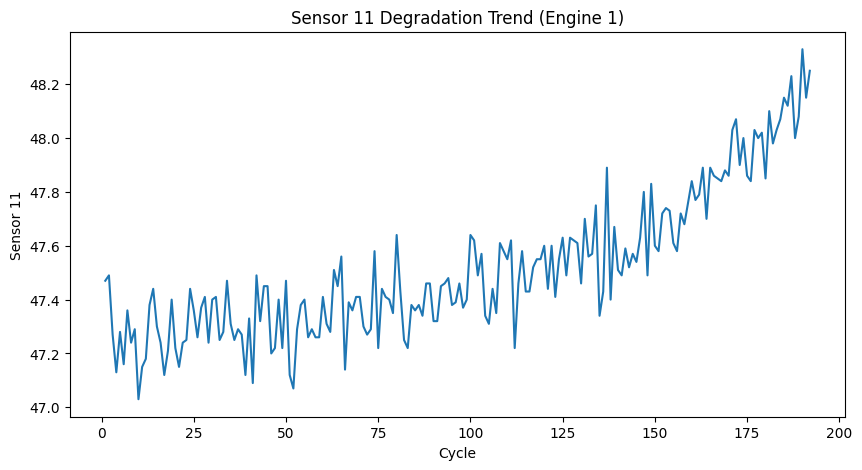

In [12]:
import matplotlib.pyplot as plt

engine_1 = train[train['unit_number'] == 1]

plt.figure(figsize=(10,5))
plt.plot(engine_1['time_in_cycles'], engine_1['sensor_11'])
plt.xlabel("Cycle")
plt.ylabel("Sensor 11")
plt.title("Sensor 11 Degradation Trend (Engine 1)")
plt.show()

## Correlation Heatmap.

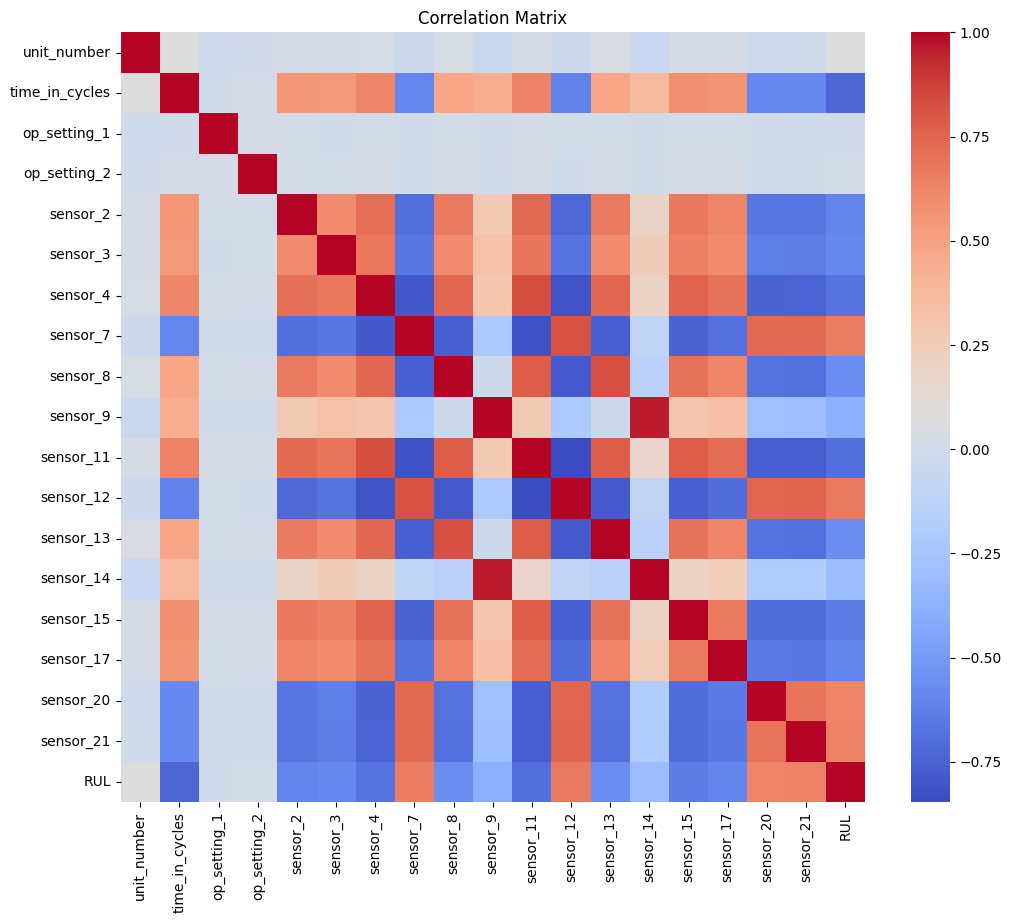

In [13]:
import seaborn as sns

plt.figure(figsize=(12,10))
sns.heatmap(train.corr(), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

## 4. Normalization.

In [15]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

feature_cols = train.columns.drop(['unit_number', 'time_in_cycles', 'RUL'])

train[feature_cols] = scaler.fit_transform(train[feature_cols])
test[feature_cols] = scaler.transform(test[feature_cols])

## 5. Visualization of data before base line model.

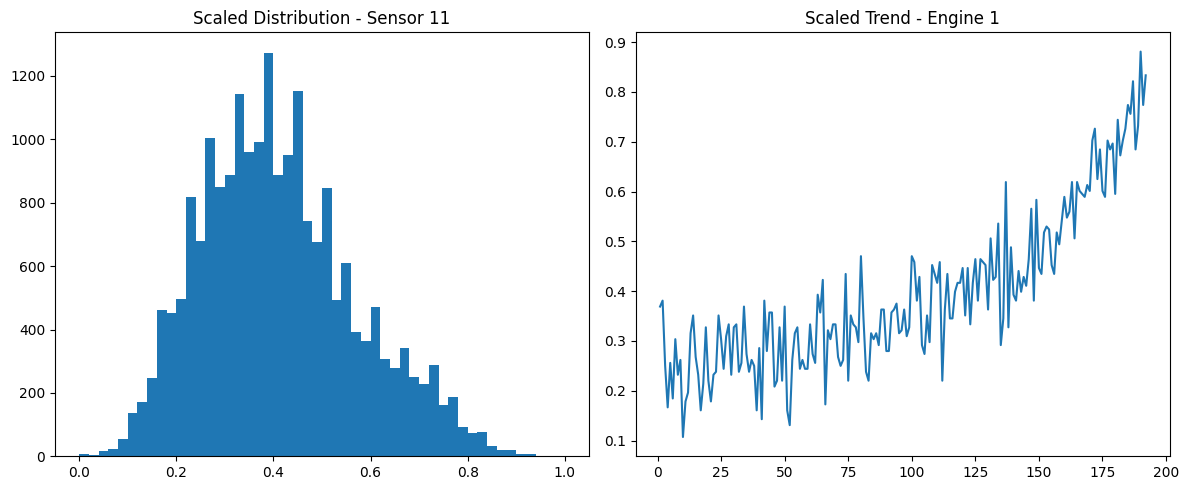

In [16]:
# 1. Distribution Before vs After Scaling

import matplotlib.pyplot as plt

sensor = 'sensor_11'

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(train[sensor], bins=50)
plt.title("Scaled Distribution - Sensor 11")

plt.subplot(1,2,2)
plt.plot(train[train['unit_number']==1]['time_in_cycles'],
         train[train['unit_number']==1][sensor])
plt.title("Scaled Trend - Engine 1")

plt.tight_layout()
plt.show()

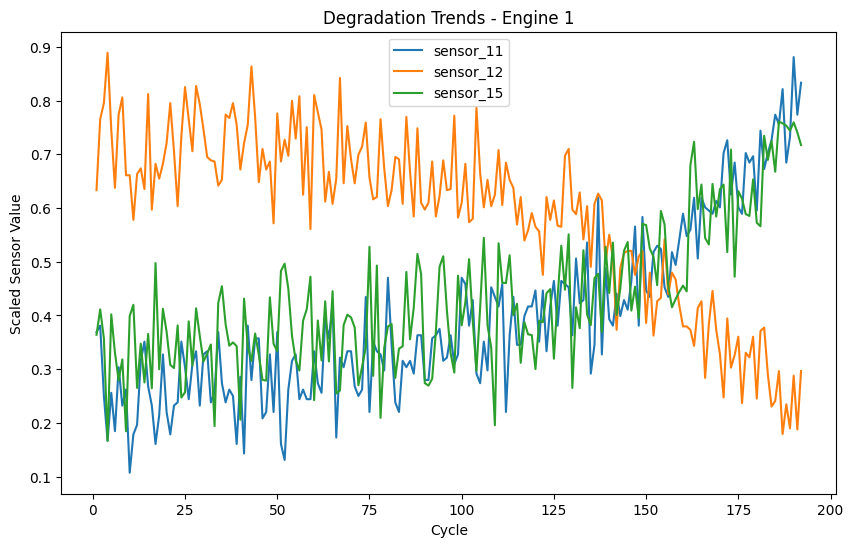

In [18]:
# 2. Compare Multiple Sensors Trend (Engine 1).

engine_1 = train[train['unit_number'] == 1]

plt.figure(figsize=(10,6))

for sensor in ['sensor_11', 'sensor_12', 'sensor_15']:
    plt.plot(engine_1['time_in_cycles'], engine_1[sensor], label=sensor)

plt.xlabel("Cycle")
plt.ylabel("Scaled Sensor Value")
plt.title("Degradation Trends - Engine 1")
plt.legend()
plt.show()

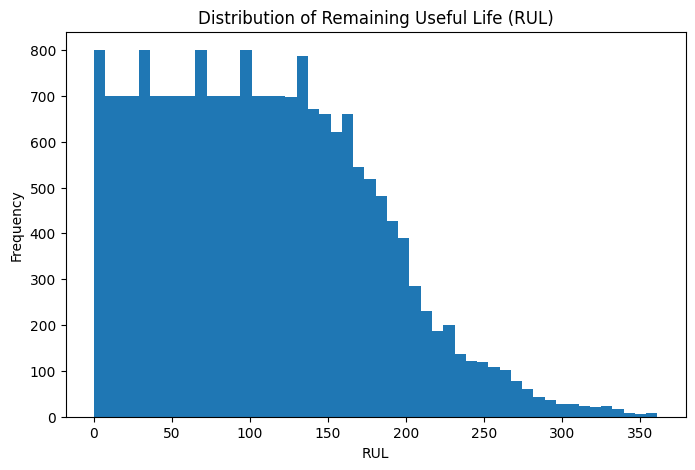

In [19]:
# 3. RUL Distribution.

plt.figure(figsize=(8,5))
plt.hist(train['RUL'], bins=50)
plt.title("Distribution of Remaining Useful Life (RUL)")
plt.xlabel("RUL")
plt.ylabel("Frequency")
plt.show()

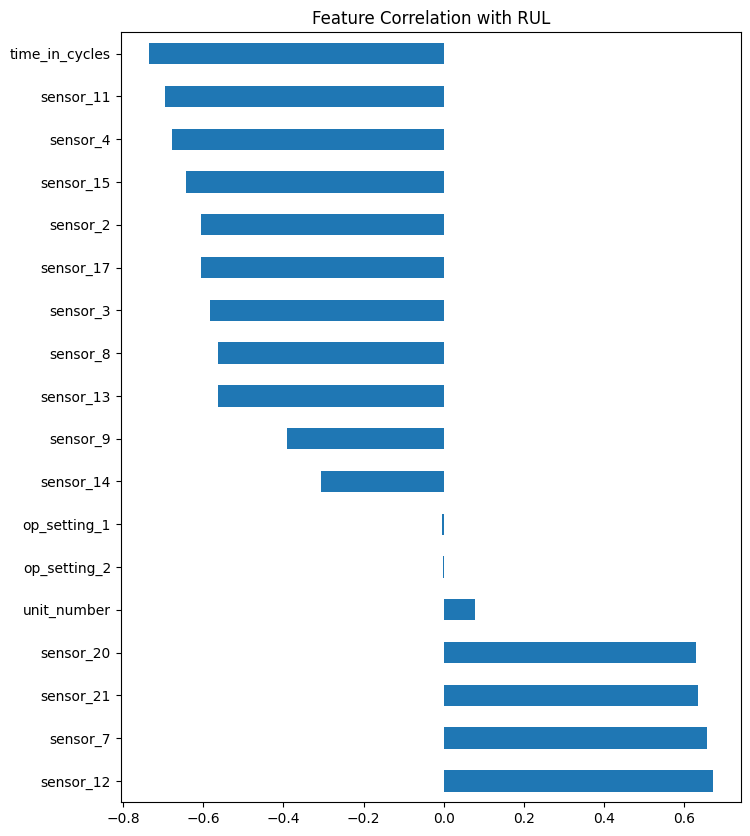

In [21]:
# 4. Correlation With RUL (After Cleaning).

corr = train.corr()['RUL'].sort_values(ascending=False)

plt.figure(figsize=(8,10))
corr.drop(['RUL']).plot(kind='barh')
plt.title("Feature Correlation with RUL")
plt.show()

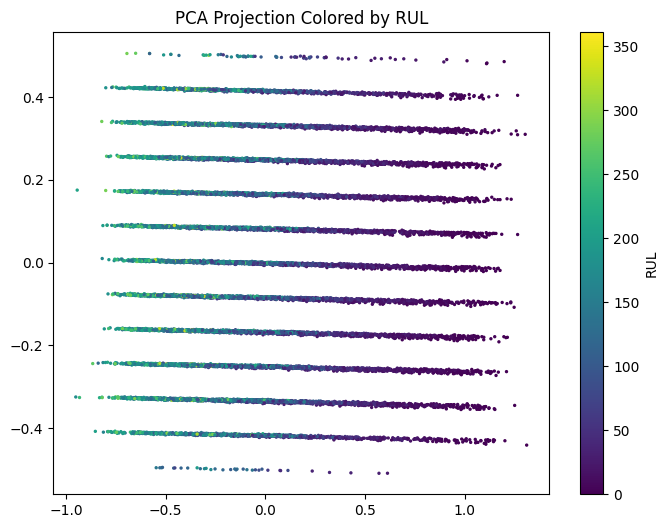

In [22]:
# 5. PCA Visualization.

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(train[feature_cols])

plt.figure(figsize=(8,6))
plt.scatter(pca_data[:,0], pca_data[:,1],
            c=train['RUL'], cmap='viridis', s=2)
plt.colorbar(label='RUL')
plt.title("PCA Projection Colored by RUL")
plt.show()

## 6. Base Line Modelling.


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

X = train[feature_cols]
y = train['RUL']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

preds = model.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, preds))
print("Baseline RMSE:", rmse)

Baseline RMSE: 44.352887499125195
